In [77]:
# %reload_ext autoreload
# %autoreload 2


In [78]:
import numpy as np
import torch


seed = 1712
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_default_dtype(torch.float32) 


In [89]:
batch_size = 32
cen_hidden_channels = 128
cen_num_gnn_layers = 3

num_train = 500
num_test = 450
num_eval = 50

# Centralized
num_epochs_cen = 1000
cen_lr = 1e-3 # 5e-3  the the best results

# Decentralized
num_rounds = 50
num_epochs = 1
eval_round = num_rounds//10

lr = 5e-3 # 2e-2 bad
step_size = num_rounds//4
gamma = 0.5
client_fraction = 0.6


In [90]:
num_ue = 25
num_ap = 40
num_antenna = 1
tau=20; power_f=0.2; D=1; f=1900; Hb=15; Hm=1.65; d0=0.01;d1=0.05;


noise_p = 10**((-203.975+10*np.log10(20*10**6)+9)/10);
rho_d = power_f/noise_p
rho_p = power_f/noise_p

In [91]:
num_clients = num_ap
eval_round = eval_round if eval_round else num_rounds//10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Create Data

In [92]:
import scipy.io


file_name = f'sumrate/dl_sumrate_data_1000_{num_ue}_{num_ap}_{num_ue}'
mat_data = scipy.io.loadmat('Data/' + file_name + '.mat')
beta_all = mat_data['betas']
gamma_all = mat_data['Gammas']
# power_all = mat_data['power']/rho_d
phi_all = mat_data['Phii_cf'].transpose(0, 2, 1)
rates_equal_solutions = mat_data['R_equal'][0]
rates_frac_solutions = mat_data['R_frac'][0]
rates_log_solutions = mat_data['R_log'][0]
label_all = None


perm = np.random.RandomState(seed).permutation(beta_all.shape[0])
train_idx = perm[:num_train]
test_idx  = perm[num_train: num_train + num_test]
eval_idx  = perm[-num_eval:]



In [93]:
from Utils.data_gen import build_cen_loader, build_decen_loader


## Centralized Data
train_data_cen, train_loader_cen = build_cen_loader(
    beta_all[train_idx],
    gamma_all[train_idx], 
    phi_all[train_idx],
    batch_size, isShuffle=True
)
test_data_cen, test_loader_cen = build_cen_loader(
    beta_all[test_idx], 
    gamma_all[test_idx],
    phi_all[test_idx], 
    batch_size
)
eval_data_cen, eval_loader_cen = build_cen_loader(
    beta_all[eval_idx], 
    gamma_all[eval_idx],
    phi_all[eval_idx], 
    num_eval
)

## Init model 


In [94]:
ap_dim = train_data_cen[0]['AP'].x.shape[1]
ue_dim = train_data_cen[0]['UE'].x.shape[1]
edge_dim = train_data_cen[0]['down'].edge_attr.shape[1]
tt_meta = [('UE', 'up', 'AP'), ('AP', 'down', 'UE')]
dim_dict = {
    'UE': ue_dim,
    'AP': ap_dim,
    'edge': edge_dim,        
}


In [95]:
from Models.GNN import APHetNet
cen_model = APHetNet(
    metadata=tt_meta,
    dim_dict=dim_dict,
    out_channels=cen_hidden_channels,
    num_layers=cen_num_gnn_layers//2,
    hid_layers=cen_hidden_channels//2,
).to(device)
torch.nn.utils.clip_grad_norm_(cen_model.parameters(), 1.0)
# cen_optimizer = torch.optim.Adam(cen_model.parameters(), lr=cen_lr)
cen_optimizer = torch.optim.AdamW(
    cen_model.parameters(), lr=cen_lr, weight_decay=1e-4
)


cen_scheduler = torch.optim.lr_scheduler.StepLR(
    cen_optimizer, step_size=num_epochs_cen//10, gamma=0.8
)

# Training

In [96]:
from Utils.centralized_train import cen_eval_sumrate, cen_train_sumrate, cen_loss_function_sumrate
from datetime import datetime, timedelta
import time


start_time = datetime.now().strftime("%Y%m%d-%H%M%S")
print(f"\n ===={start_time}==== Training Centralized GNN ... ")
start_time = time.time()
all_rate = []
all_rate_test = []
eval_epochs_cen = num_epochs_cen//10 if num_epochs_cen//10 else 1
print(f'Training Centralized GNN for benchmark...')
print(f'Optimal rate: train {np.mean(rates_log_solutions[train_idx])}, test {np.mean(rates_log_solutions[test_idx])}')
for epoch in range(num_epochs_cen):
    cen_model.train()
    train_loss = cen_train_sumrate(
        epoch/(2*num_epochs_cen//3),
        train_loader_cen, cen_model, cen_optimizer,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
    )
    
    cen_model.eval()
    with torch.no_grad():
        train_eval = cen_eval_sumrate(
            train_loader_cen, cen_model,
            tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
        )   
        test_eval = cen_eval_sumrate(
            test_loader_cen, cen_model,
            tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna
        )  
    all_rate.append(train_eval)    
    all_rate_test.append(test_eval)    
    cen_scheduler.step()
    if epoch%eval_epochs_cen==0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Rate: {train_eval:.4f} | "
            f"Test Rate: {test_eval:.4f} "
        )
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {timedelta(seconds=execution_time)}")


 ====20260730-152517==== Training Centralized GNN ... 
Training Centralized GNN for benchmark...
Optimal rate: train 26.696402696171965, test 26.729134925716977
Epoch 001/1000 | Train Loss: -19.9376 | Train Rate: 21.1303 | Test Rate: 21.1506 
Epoch 101/1000 | Train Loss: -25.2817 | Train Rate: 25.3921 | Test Rate: 25.3801 
Epoch 201/1000 | Train Loss: -25.4108 | Train Rate: 25.4793 | Test Rate: 25.4558 
Epoch 301/1000 | Train Loss: -25.5017 | Train Rate: 25.6507 | Test Rate: 25.6037 
Epoch 401/1000 | Train Loss: -25.5679 | Train Rate: 25.6740 | Test Rate: 25.6115 
Epoch 501/1000 | Train Loss: -25.6183 | Train Rate: 25.6492 | Test Rate: 25.5937 
Epoch 601/1000 | Train Loss: -25.6286 | Train Rate: 25.7003 | Test Rate: 25.6209 
Epoch 701/1000 | Train Loss: -25.6563 | Train Rate: 25.6705 | Test Rate: 25.6058 
Epoch 801/1000 | Train Loss: -25.6664 | Train Rate: 25.7639 | Test Rate: 25.6673 
Epoch 901/1000 | Train Loss: -25.6842 | Train Rate: 25.7552 | Test Rate: 25.6623 
Execution Time: 0:

# Visualization

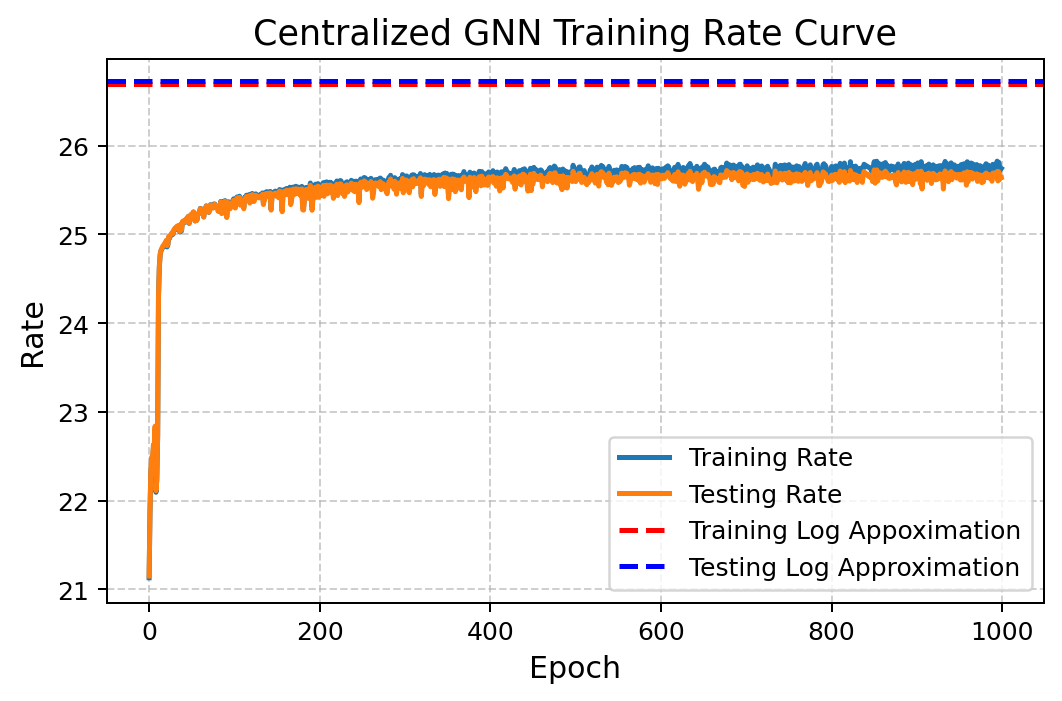

In [97]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4), dpi=180)
plt.plot(all_rate, label='Training Rate', linewidth=2)
plt.plot(all_rate_test, label='Testing Rate', linewidth=2)
plt.axhline(y=np.mean(rates_log_solutions[train_idx]), linewidth=2, color='r', linestyle='--', label='Training Log Appoximation')
plt.axhline(y=np.mean(rates_log_solutions[test_idx]), linewidth=2, color='b', linestyle='--', label='Testing Log Approximation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.title('Centralized GNN Training Rate Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
# figure_name = f'{timestamp}_cen'
# save_path = TRAIN_DIR + f'{figure_name}.png' 
# plt.savefig(save_path, dpi=300)  

In [ ]:
cen_model.eval()
for batch in eval_loader_cen:
    batch = batch.to(device)
    num_graph = batch.num_graphs
    x_dict, edge_dict, edge_index = cen_model(batch)
    
    gnn_rates, all_one_rates = cen_loss_function_sumrate(
        batch, x_dict, edge_dict,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna, 
        eval_mode=True
    )


gnn_rates = gnn_rates.detach().cpu().numpy() 
all_one_rates = all_one_rates.detach().cpu().numpy()
rates_equal = rates_equal_solutions[eval_idx] 
rates_frac = rates_frac_solutions[eval_idx] 
rates_log = rates_log_solutions[eval_idx] 

# Total parameters in cen_model
total_params = sum(p.numel() for p in cen_model.parameters())

# Only trainable parameters (requires_grad = True)
trainable_params = sum(
    p.numel() for p in cen_model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f'Mean Rate of GNN: {np.mean(gnn_rates):.2f}')
print(f'Mean Rate of log-approx: {np.mean(rates_log):.2f}')

Total parameters: 233,893
Trainable parameters: 233,893
Mean Rate of GNN: 25.59
Mean Rate of log-approx: 26.69


: 

In [ ]:
# 40 20 20
# Trainable parameters: 58,980
# Mean Rate of GNN: 24.59

# 60 20 20
# Trainable parameters: 58,980
# Mean Rate of GNN: 31.58
# Mean Rate of log-approx: 30.79

# 80 20 20
# Trainable parameters: 58,980
# Mean Rate of GNN: 38.31
# Mean Rate of log-approx: 37.75

# 40 25 25
# Trainable parameters: 59,205
# Mean Rate of GNN: 25.57
# Mean Rate of log-approx: 26.69

# 60 25 25
# Trainable parameters: 59,205
# Mean Rate of GNN: 34.08
# Mean Rate of log-approx: 35.68

# 80 25 25
# Trainable parameters: 59,205
# Mean Rate of GNN: 40.72
# Mean Rate of log-approx: 42.70

In [26]:
# max_value = np.ceil(max(np.max(all_one_rates), np.max(gnn_rates), np.max(rates_equal), np.max(rates_frac), np.max(rates_log))*100)/100
    
# min_rate, max_rate = 0, max_value
# # y_axis = np.arange(0, 1.0, 1/202)
# y_axis = np.linspace(0, 1, num_eval+2)
# gnn_rates.sort();  all_one_rates.sort(); 
# rates_equal.sort(); rates_frac.sort(); rates_log.sort()
# gnn_rates = np.insert(gnn_rates, 0, min_rate); gnn_rates = np.insert(gnn_rates,num_eval+1,max_rate)
# all_one_rates = np.insert(all_one_rates, 0, min_rate); all_one_rates = np.insert(all_one_rates,num_eval+1,max_rate)
# rates_equal = np.insert(rates_equal, 0, min_rate); rates_equal = np.insert(rates_equal,num_eval+1,max_rate)
# rates_frac = np.insert(rates_frac, 0, min_rate); rates_frac = np.insert(rates_frac,num_eval+1,max_rate)
# rates_log = np.insert(rates_log, 0, min_rate); rates_log = np.insert(rates_log,num_eval+1,max_rate)

# plt.figure(figsize=(6,4), dpi=180)
# # plt.plot(all_one_rates, y_axis, label = 'Maximum Power', linewidth=2)
# plt.plot(gnn_rates, y_axis, label = 'Centralized GNN', linewidth=2)
# # plt.plot(opt_rates, y_axis, label = 'Optimal', linewidth=2)
# plt.plot(rates_equal, y_axis, label = 'Equal Power', linewidth=2)
# # plt.plot(rates_frac, y_axis, label = 'Fractional Power', linewidth=2)
# plt.plot(rates_log, y_axis, label = 'Log Approx.', linewidth=2)
# plt.xlabel('Sum rate [bps/Hz]', {'fontsize':16})
# plt.ylabel('Empirical CDF', {'fontsize':16})
# plt.legend(fontsize = 14)
# plt.grid()